We check if the predictions from our theory match the simulations for the upcrossing process for the various correlation functions.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
import scipy.linalg
from tqdm import tqdm
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process
from matplotlib.ticker import FuncFormatter, LogLocator, MaxNLocator

### Testing the distribution of counts of upcrossings.

In [2]:
# Simulation parameters.
T = 10.0                 # Total simulation time.
tau = 0.06            # Correlation decay parameter for the process.
dt = 0.1 * tau
sigma = 1.0             # Standard deviation (amplitude) of the process.
u = 0.5                 # Threshold for upcrossings.
n_trials = 1000      # Number of simulation trials.

alpha = 3/2

# Containers for simulation results.
upcrossings_counts = np.zeros(n_trials)

# Run the simulations.
for trial in range(n_trials):
    # Simulate one sample path of the process.
    t, x = utils.simulate_gaussian_process_fft(
        process.r_rational_quadratic, T, dt, sigma=sigma, tau=tau, alpha=alpha
    )
    # Count the number of upcrossings at threshold u.
    upcrossings_counts[trial] = utils.count_upcrossings(x, threshold=u)

Simulation results:
Mean upcrossings: 23.2930
Variance of upcrossings: 11.7172
Fano factor (variance/mean): 0.5030

Analytical results:
Expected number of upcrossings (mean): 23.4090
Variance of upcrossings: 10.6778
Fano factor (variance/mean): 0.4561

Analytical results using CLT:
Variance of upcrossings: 10.5893
Fano factor (variance/mean): 0.4524


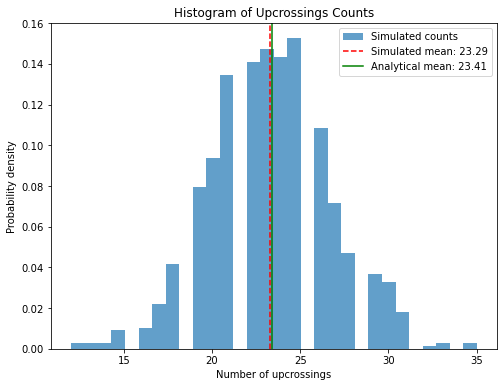

In [3]:
# Calculate empirical statistics.
sim_mean = np.mean(upcrossings_counts)
sim_var = np.var(upcrossings_counts)
sim_fano = sim_var / sim_mean if sim_mean != 0 else np.nan

print("Simulation results:")
print(f"Mean upcrossings: {sim_mean:.4f}")
print(f"Variance of upcrossings: {sim_var:.4f}")
print(f"Fano factor (variance/mean): {sim_fano:.4f}")

# Compute analytical results using your GaussianUpCrossingsDimless class.
# (Note: the analytical formulas assume a dimensionless time scale with tau set to 1 in r(t).
# Here we pass tau=tau to keep parameters consistent with the simulation.)
gaussian_up = formula.GaussianUpCrossingsDimless(r_func=process.r_rational_quadratic, u=u, tau=tau, alpha=alpha, sigma=sigma)

analytical_mean = gaussian_up.upcrossing_mean(T, u=u).item()
analytical_variance = gaussian_up.upcrossing_variance(T, u=u).item()
analytical_fano = gaussian_up.upcrossing_fano_factor(T, u=u).item()

print("\nAnalytical results:")
print(f"Expected number of upcrossings (mean): {analytical_mean:.4f}")
print(f"Variance of upcrossings: {analytical_variance:.4f}")
print(f"Fano factor (variance/mean): {analytical_fano:.4f}")

# print the CLT results as well
analytical_variance_CLT = gaussian_up.upcrossing_variance_CLT(T, u=u).item()
analytical_fano_CLT = gaussian_up.upcrossing_fano_factor_CLT(u=u).item()

print("\nAnalytical results using CLT:")
print(f"Variance of upcrossings: {analytical_variance_CLT:.4f}")
print(f"Fano factor (variance/mean): {analytical_fano_CLT:.4f}")


# Plot histogram of simulation upcrossings counts with the analytical mean indicated.
plt.figure(figsize=(8, 6))
plt.hist(upcrossings_counts, bins=30, density=True, alpha=0.7, label="Simulated counts")
plt.axvline(sim_mean, color='r', linestyle='--', 
            label=f"Simulated mean: {sim_mean:.2f}")
plt.axvline(analytical_mean, color='g', linestyle='-', 
            label=f"Analytical mean: {analytical_mean:.2f}")
plt.xlabel("Number of upcrossings")
plt.ylabel("Probability density")
plt.title("Histogram of Upcrossings Counts")
plt.legend()
plt.show()

### We simulate the analytical vs simulation results for Fano factors.

In [5]:
# which process to use
r_func = process.r_squared_exp

# define the parameters of the model
T = 1.0                # Total simulation time.
tau = 0.05            # Second correlation parameter.
sigma = 1.0             # Standard deviation (amplitude) of the process.

params = {
    'tau': tau,
    'sigma': sigma,
    'alpha': alpha, # This will be updated below.
}

In [16]:
# define the values of u for which the result is wanted
u_list = [0.0, 0.25, 0.5]

# define the the tau values 
num_points_tau = 50
tau_min = 0.1
tau_max = 0.99
tau_vals = torch.logspace(np.log10(tau_min), np.log10(tau_max), num_points_tau)


In [17]:
# -------------------------------------------
# Save analytical results in a dictionary.
# -------------------------------------------
analytical_results = {}  # Keys are threshold u values.

for u in u_list:
    mean_vals = []
    variance_vals = []
    fano_vals = []
    
    for tau in tau_vals:
        tau_val = float(tau)
        params['tau'] = tau_val
        
        # Create GaussianUpCrossingsDimless instance with current parameters.
        gaussian_up = formula.GaussianUpCrossingsDimless(r_func=r_func, u=u, **params)
        
        # Compute analytical quantities.
        mean_vals.append(gaussian_up.upcrossing_mean(T, u=u).item())
        variance_vals.append(gaussian_up.upcrossing_variance(T, u=u).item())
        fano_vals.append(gaussian_up.upcrossing_fano_factor(T, u=u).item())
        # fano_vals.append(gaussian_up.upcrossing_fano_factor_CLT(u=u).item())
    
    # Convert lists to torch tensors.
    analytical_results[u] = {
        'mean': torch.tensor(mean_vals),
        'variance': torch.tensor(variance_vals),
        'fano_factor': torch.tensor(fano_vals),
    }

In [18]:
# --------------------------------------------------
# Compute simulation results (using FFT simulations) and store in dictionary.
# --------------------------------------------------
# Define simulation-specific parameters.
n_trials = 20000  # Number of simulation trials.

# Define the tau values.
num_points_tau_sim = 5
tau_vals_sim = torch.logspace(np.log10(tau_min), np.log10(tau_max), num_points_tau_sim)

simulation_results = {u: {} for u in u_list}  # Prepare dictionary keys for each threshold.

# For each tau value, simulate trials and compute counts for all thresholds at once.
for tau in tqdm(tau_vals_sim, desc="Simulating over tau values"):
    tau_val = float(tau)
    params['tau'] = tau_val

    dt = 0.02 * tau_val  # Time discretization step.
    
    # Create an array to store upcrossings counts for each trial and each threshold.
    # The second dimension corresponds to each threshold in u_list.
    upcrossings_counts = np.zeros((n_trials, len(u_list)))
    
    for trial in tqdm(range(n_trials), desc="Trials", leave=False):
        # Generate one sample path using FFT-based simulation.
        t, x = utils.simulate_gaussian_process_fft(r_func, T, dt, **params)
        
        # Compute upcrossings counts for all thresholds in one call.
        # Assuming count_upcrossings now supports a list of thresholds.
        counts = utils.count_upcrossings(x, threshold=u_list)  # returns a list of counts
        
        upcrossings_counts[trial, :] = counts
    
    # Compute simulation statistics for each threshold.
    sim_mean = np.mean(upcrossings_counts, axis=0)
    sim_var = np.var(upcrossings_counts, axis=0)
    # Compute Fano factor while avoiding division by zero.
    sim_fano = np.divide(sim_var, sim_mean, out=np.full_like(sim_var, np.nan), where=(sim_mean != 0))
    
    # Append the statistics to the results dictionary for each threshold.
    for i, u in enumerate(u_list):
        # If results for the current threshold already exist, append the new value.
        # Otherwise, initialize as a list.
        simulation_results[u].setdefault('mean', []).append(sim_mean[i])
        simulation_results[u].setdefault('variance', []).append(sim_var[i])
        simulation_results[u].setdefault('fano_factor', []).append(sim_fano[i])

# Convert lists to torch tensors for each threshold.
for u in simulation_results:
    simulation_results[u]['mean'] = torch.tensor(simulation_results[u]['mean'])
    simulation_results[u]['variance'] = torch.tensor(simulation_results[u]['variance'])
    simulation_results[u]['fano_factor'] = torch.tensor(simulation_results[u]['fano_factor'])


Simulating over tau values: 100%|██████████| 5/5 [00:34<00:00,  6.97s/it]


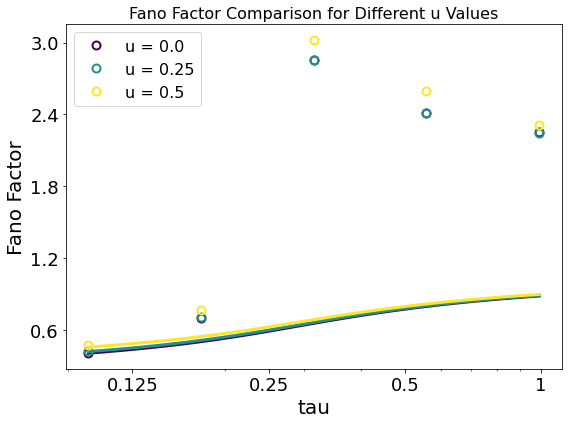

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(u_list)))  # Generate distinct colors

for u, color in zip(u_list, colors):
    analytical_fano = analytical_results[u]['fano_factor'].numpy()
    simulation_fano = simulation_results[u]['fano_factor'].numpy()

    # Plot the analytical curve with a thicker solid line.
    ax.plot(tau_vals.numpy(), analytical_fano, linewidth=3, linestyle='-', color=color, label='_nolegend_')
    
    # Plot the simulation results as open circles in the same color.
    ax.plot(tau_vals_sim.numpy(), simulation_fano, marker='o', markersize=8, linestyle='None',
            color=color, markerfacecolor='none', markeredgewidth=2, label=f"u = {u}")

ax.set_title("Fano Factor Comparison for Different u Values", fontsize=16)
ax.set_xlabel("tau", fontsize=20)
ax.set_ylabel("Fano Factor", fontsize=20)
ax.set_xscale('log')  # Use a logarithmic scale for the x-axis.

# Increase tick label sizes.
ax.tick_params(axis='both', which='major', labelsize=18)

# Use FuncFormatter to display plain numbers on the x-axis.
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:g}"))

# Use LogLocator for equidistant ticks in log-space.
ax.xaxis.set_major_locator(LogLocator(base=2.0, numticks=5))

# Use MaxNLocator for the y-axis if desired.
ax.yaxis.set_major_locator(MaxNLocator(5))

# Only add the legend for simulation markers.
ax.legend(fontsize=16)

plt.tight_layout()
plt.show()


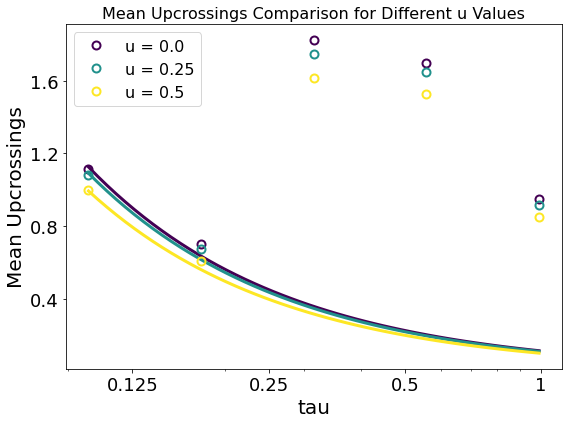

In [20]:
# Plot mean upcrossings comparison for different u values
fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(u_list)))  # Generate distinct colors

for u, color in zip(u_list, colors):
    analytical_mean = analytical_results[u]['mean'].numpy()
    simulation_mean = simulation_results[u]['mean'].numpy()

    # Plot the analytical curve with a thicker solid line.
    ax.plot(tau_vals.numpy(), analytical_mean, linewidth=3, linestyle='-', color=color, label='_nolegend_')
    
    # Plot the simulation results as open circles in the same color.
    ax.plot(tau_vals_sim.numpy(), simulation_mean, marker='o', markersize=8, linestyle='None',
            color=color, markerfacecolor='none', markeredgewidth=2, label=f"u = {u}")

ax.set_title("Mean Upcrossings Comparison for Different u Values", fontsize=16)
ax.set_xlabel("tau", fontsize=20)
ax.set_ylabel("Mean Upcrossings", fontsize=20)
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(LogLocator(base=2.0, numticks=5))
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()


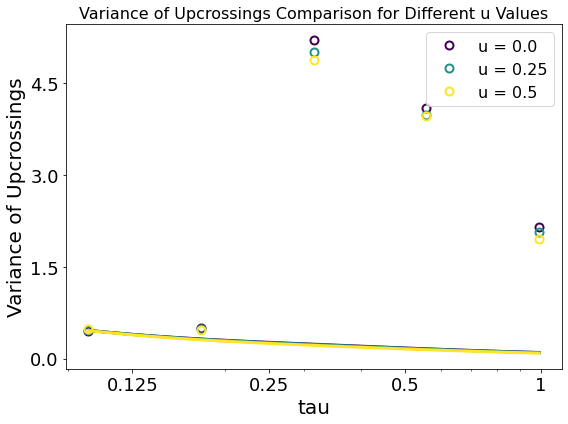

In [21]:
# Plot variance of upcrossings comparison for different u values
fig, ax = plt.subplots(figsize=(8, 6))

for u, color in zip(u_list, colors):
    analytical_variance = analytical_results[u]['variance'].numpy()
    simulation_variance = simulation_results[u]['variance'].numpy()

    # Plot the analytical curve with a thicker solid line.
    ax.plot(tau_vals.numpy(), analytical_variance, linewidth=3, linestyle='-', color=color, label='_nolegend_')
    
    # Plot the simulation results as open circles in the same color.
    ax.plot(tau_vals_sim.numpy(), simulation_variance, marker='o', markersize=8, linestyle='None',
            color=color, markerfacecolor='none', markeredgewidth=2, label=f"u = {u}")

ax.set_title("Variance of Upcrossings Comparison for Different u Values", fontsize=16)
ax.set_xlabel("tau", fontsize=20)
ax.set_ylabel("Variance of Upcrossings", fontsize=20)
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(LogLocator(base=2.0, numticks=5))
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()


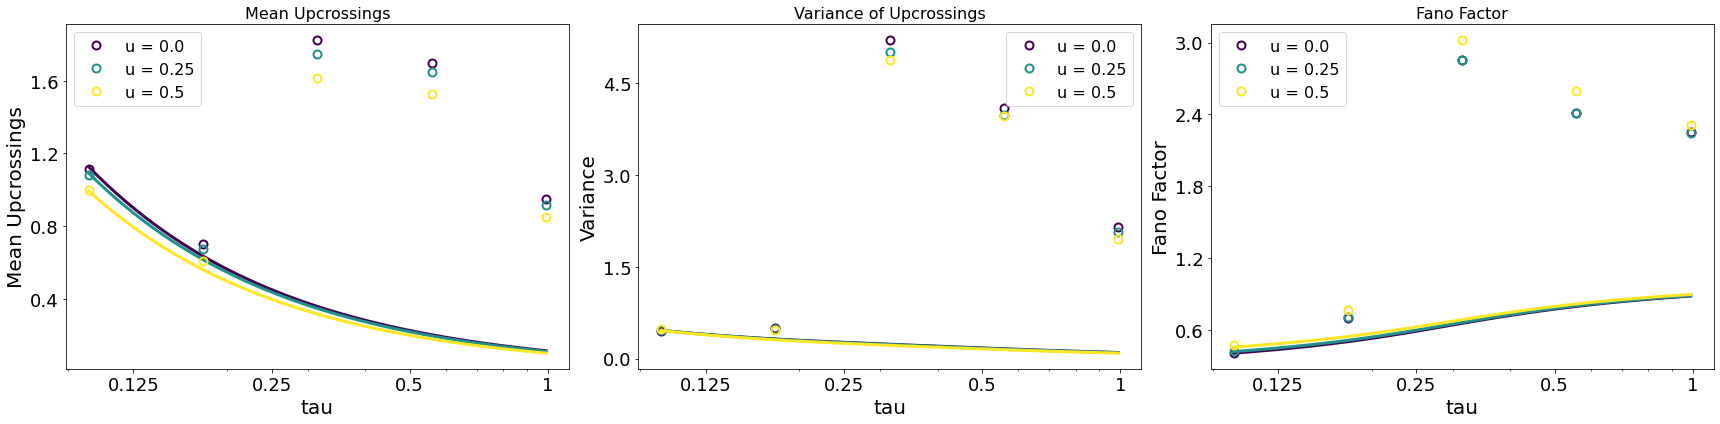

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator, MaxNLocator

# Assume u_list, analytical_results, simulation_results, 
# tau_vals, and tau_vals_sim are already defined.

# Create a figure with 1 row and 3 columns of subplots.
fig, axs = plt.subplots(1, 3, figsize=(24, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(u_list)))  # Generate distinct colors

# ---------------- Plot 1: Mean Upcrossings Comparison ----------------
ax = axs[0]
for u, color in zip(u_list, colors):
    analytical_mean = analytical_results[u]['mean'].numpy()
    simulation_mean = simulation_results[u]['mean'].numpy()
    
    # Analytical curve with a thicker solid line.
    ax.plot(tau_vals.numpy(), analytical_mean, linewidth=3, linestyle='-', color=color, label='_nolegend_')
    # Simulation results as open circles.
    ax.plot(tau_vals_sim.numpy(), simulation_mean, marker='o', markersize=8, linestyle='None',
            color=color, markerfacecolor='none', markeredgewidth=2, label=f"u = {u}")

ax.set_title("Mean Upcrossings", fontsize=16)
ax.set_xlabel("tau", fontsize=20)
ax.set_ylabel("Mean Upcrossings", fontsize=20)
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(LogLocator(base=2.0, numticks=5))
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.legend(fontsize=16)

# ---------------- Plot 2: Variance of Upcrossings Comparison ----------------
ax = axs[1]
for u, color in zip(u_list, colors):
    analytical_variance = analytical_results[u]['variance'].numpy()
    simulation_variance = simulation_results[u]['variance'].numpy()
    
    # Analytical curve with a thicker solid line.
    ax.plot(tau_vals.numpy(), analytical_variance, linewidth=3, linestyle='-', color=color, label='_nolegend_')
    # Simulation results as open circles.
    ax.plot(tau_vals_sim.numpy(), simulation_variance, marker='o', markersize=8, linestyle='None',
            color=color, markerfacecolor='none', markeredgewidth=2, label=f"u = {u}")

ax.set_title("Variance of Upcrossings", fontsize=16)
ax.set_xlabel("tau", fontsize=20)
ax.set_ylabel("Variance", fontsize=20)
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(LogLocator(base=2.0, numticks=5))
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.legend(fontsize=16)

# ---------------- Plot 3: Fano Factor Comparison ----------------
ax = axs[2]
for u, color in zip(u_list, colors):
    analytical_fano = analytical_results[u]['fano_factor'].numpy()
    simulation_fano = simulation_results[u]['fano_factor'].numpy()
    
    # Analytical curve with a thicker solid line.
    ax.plot(tau_vals.numpy(), analytical_fano, linewidth=3, linestyle='-', color=color, label='_nolegend_')
    # Simulation results as open circles.
    ax.plot(tau_vals_sim.numpy(), simulation_fano, marker='o', markersize=8, linestyle='None',
            color=color, markerfacecolor='none', markeredgewidth=2, label=f"u = {u}")

ax.set_title("Fano Factor", fontsize=16)
ax.set_xlabel("tau", fontsize=20)
ax.set_ylabel("Fano Factor", fontsize=20)
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(LogLocator(base=2.0, numticks=5))
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.legend(fontsize=16)

plt.tight_layout()
plt.show()
